# Process Zillow Home Value Index

Load and transform the Zillow home value index. 

Uses geopy library. Run `%pip install geopy` in the ipynb

- Append latitute, longitude per msa

## Dependencies

In [1]:
# %pip install geopy
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import pytest
import seaborn as sns

In [2]:
import os
import sys
project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if project_root not in sys.path:
    sys.path.append(project_root)
from src.geocoder import Geocoder

In [3]:
class ZillowData():
    DTYPES = {
        'RegionID': 'int64',
        'SizeRank': 'int64',
        'RegionName': 'string',
        'RegionType': 'string',
        'StateName': 'string'
    }
    
    META_DATA_COLS = ['RegionID', 'SizeRank', 'RegionName', 'RegionType',
                      'StateName', 'latitude', 'longitude']
    
    def __init__(self, raw_data_path, geocoder=None):
        self.df = pd.read_csv(raw_data_path, dtype=self.DTYPES)
        all_columns = self.df.columns.tolist() + [col for col in self.META_DATA_COLS if col not in self.df.columns]
        self.df = self.df.reindex(columns=all_columns)
        self.geocoder=geocoder
        
    def region_time_series(self, region):
        """
        Returns DataFrame with one column of time series data
        """

        regional = self.df[self.df['RegionName']==region]
        regional_data = regional.loc[:, self.date_cols()].T
        regional_data.columns = [region]
        regional_data.index = pd.to_datetime(regional_data.index)
        return regional_data
    
    def normalized_from_date(self, start_date):
        """
        Returns a DataFrame that is scaled to 100 as of the start_date
        """
        start_date = pd.to_datetime(start_date)
        
        all_dates = self.date_cols()
        result_dates = [date for date in all_dates if pd.to_datetime(date) >= start_date]
        result_cols = self.META_DATA_COLS + result_dates
        first_date = result_dates[0]
        latest_date = result_dates[-1]
        
        normalized_df = self.df[result_cols].copy()
        normalized_df = normalized_df.dropna(subset=[first_date])
        
        baseline = normalized_df[first_date] / 100
        normalized_df[result_dates] = normalized_df[result_dates].div(baseline, axis=0)
        return normalized_df

    def change_after_event(self, event_date, regions=[]):
        """
        Returns a DataFrame with the normalized index for a set of region
        1, 2, 3, 6, 12 months after an event data
        """
        norm_df = self.normalized_from_date(event_date)
        if regions:
            norm_df = norm_df[norm_df['RegionName'].isin(regions)]
        available_dates = [col for col in norm_df.columns if col not in self.META_DATA_COLS]
        event_date = pd.to_datetime(available_dates[0])
        intervals = [1, 2, 3, 6, 12]
        results = norm_df[self.META_DATA_COLS].copy()
        
        for m in intervals:
            target_date = event_date + pd.DateOffset(months=m)
            closest_date_col = min(available_dates, key=lambda x: abs(pd.to_datetime(x) - target_date))
            results[f'plus_{m}_mon'] = norm_df[closest_date_col]
            
        return results

    def latest_date(self):
        return self.date_cols()[-1]

    def date_cols(self):
        dates = [col for col in self.df.columns if col not in self.META_DATA_COLS]
        dates = sorted(dates, key=pd.to_datetime)
        return list(dates)
    
    def geocode_regions(self, regions=[]):
        mask = self.df["RegionName"].isin(regions)
        indices = self.df[mask].index
        for idx in indices:
            query = self.df.at[idx, 'RegionName']
            location = self.geocoder.geocode(query)
            self.df.at[idx, 'latitude'] = location['latitude']
            self.df.at[idx, 'longitude'] = location['longitude']
        return self.df.loc[indices, ['RegionName', "latitude", "longitude"]]


In [4]:
cache_file = Path('../data/processed/geolocations.csv')
geocoder = Geocoder(cache_file)

## Load raw data from csv

In [5]:
zhvi_raw = Path('../data/raw/ZHVI_2026_01_08_raw.csv')
assert zhvi_raw.exists()

In [6]:
zhvi = ZillowData(zhvi_raw, geocoder)
zhvi.df.head()

,RegionID,SizeRank,RegionName,RegionType,StateName,2000-01-31,2000-02-29,2000-03-31,2000-04-30,2000-05-31,...,2025-04-30,2025-05-31,2025-06-30,2025-07-31,2025-08-31,2025-09-30,2025-10-31,2025-11-30,latitude,longitude
0,102001,0,United States,country,<NA>,121365.463017,121578.983773,121843.780950,122411.718918,123065.347427,...,359841.918311,359161.728607,358549.348441,358126.082695,357900.244881,358139.907469,358570.726255,359241.248814,NaN,NaN
1,394913,1,"New York, NY",msa,NY,217048.914950,217971.250375,218902.128288,220788.447146,222741.795647,...,687173.496480,688933.036680,690400.936533,691567.341599,692353.209509,693746.473781,696069.806090,699394.634661,NaN,NaN
2,753899,2,"Los Angeles, CA",msa,CA,218336.580065,219149.069165,220231.296899,222384.566542,224739.568479,...,938798.754881,934095.397500,929804.957480,927250.711189,926195.042763,927236.358557,929617.284624,932886.242451,NaN,NaN
3,394463,3,"Chicago, IL",msa,IL,151721.660042,151862.110101,152129.599712,152795.047391,153595.500906,...,327914.592965,328201.936285,328558.836926,329388.734181,330373.317156,331691.388829,332981.532008,334511.786740,NaN,NaN
4,394514,4,"Dallas, TX",msa,TX,126887.587653,126944.103828,127009.074957,127177.798153,127400.255068,...,368886.369472,366484.365155,364134.164489,362129.302053,360775.171809,360131.881806,359785.324832,359523.202747,NaN,NaN


In [7]:
latest_month = zhvi.latest_date()
assert latest_month == '2025-11-30'
print(f"Latest data is from: {latest_month}")

Latest data is from: 2025-11-30


In [8]:
"""check the data types"""
df = zhvi.df

assert df.dtypes['RegionID'] == 'int64'
assert df.dtypes['SizeRank'] == 'int64'
assert df.dtypes['RegionName'] == 'string'
assert df.dtypes['RegionType'] == 'string'
assert df.dtypes['StateName'] == 'string'
assert df.dtypes['2025-11-30'] == 'float64'
assert df.dtypes['2000-01-31'] == 'float64'

## National Data

In [9]:
national = zhvi.region_time_series("United States")
assert national.columns == ["United States"], "column labeled for region"
assert len(national) == 311, "Data through 2025-11-30"
assert isinstance(national.index, pd.DatetimeIndex)
assert national.loc['2000-01-31', 'United States'] == pytest.approx(121365.46, abs=1e-2)
assert national.loc['2025-11-30', 'United States'] == pytest.approx(359241.25, abs=1e-2)

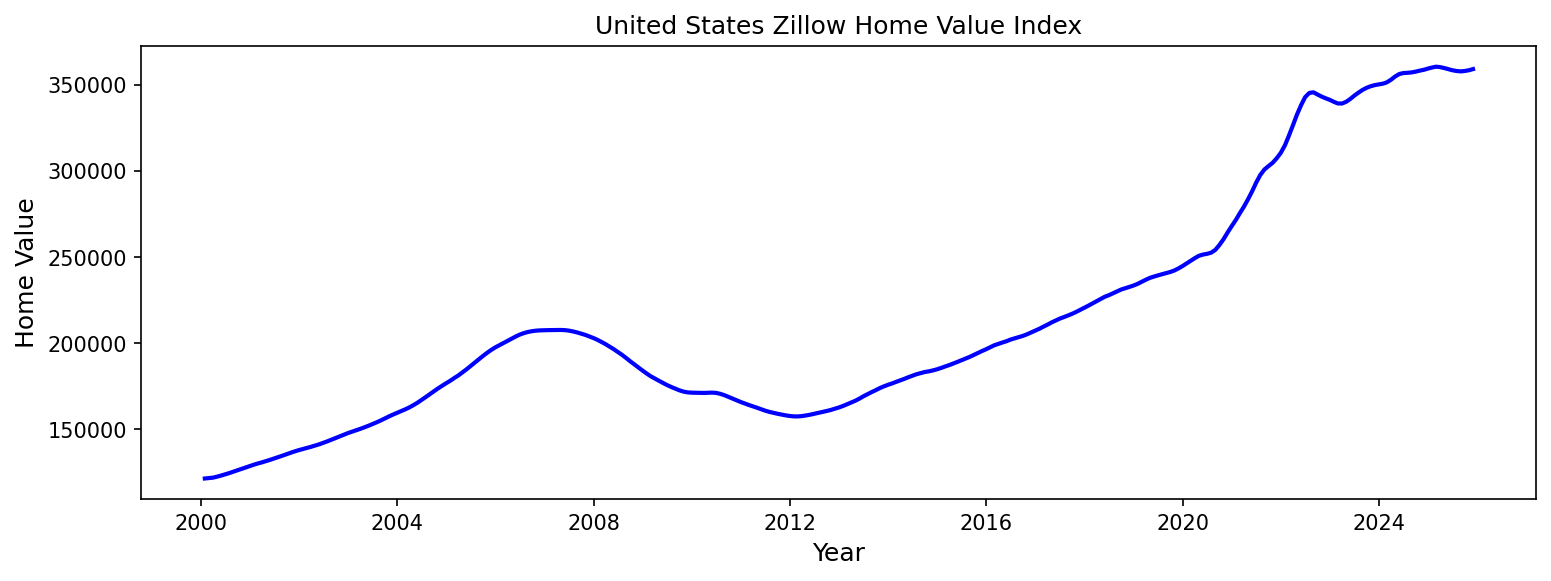

In [10]:
plt.figure(figsize=(12, 4), dpi=150)
plt.plot(national.index, national['United States'], color='blue', linewidth=2)
plt.title("United States Zillow Home Value Index")
plt.ylabel("Home Value", fontsize=12)
plt.xlabel("Year", fontsize=12)
plt.show()

## Distribution of Values

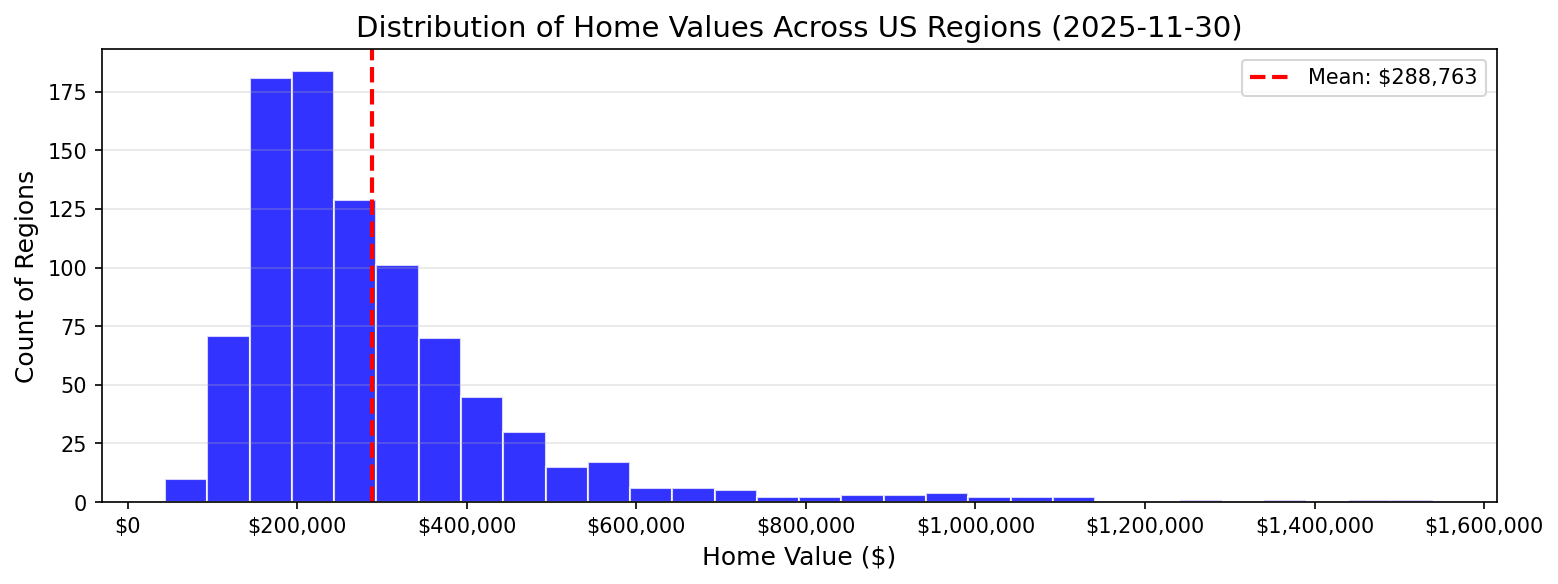

In [11]:
regions = df[df["RegionName"] != "United States"]
current = regions.loc[:, latest_month].dropna()

mean_val = current.mean()

fig, ax = plt.subplots(figsize=(12, 4), dpi=150)

ax.hist(current, bins=30, color="blue", edgecolor='white', alpha=0.8)

formatter = ticker.StrMethodFormatter('${x:,.0f}')
ax.xaxis.set_major_formatter(formatter)

ax.set_title(f'Distribution of Home Values Across US Regions ({latest_month})', fontsize=14)
ax.set_ylabel("Count of Regions", fontsize=12)
ax.set_xlabel('Home Value ($)', fontsize=12)
ax.axvline(mean_val, color='red', linestyle='dashed', linewidth=2, 
            label=f'Mean: ${mean_val:,.0f}')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.show()

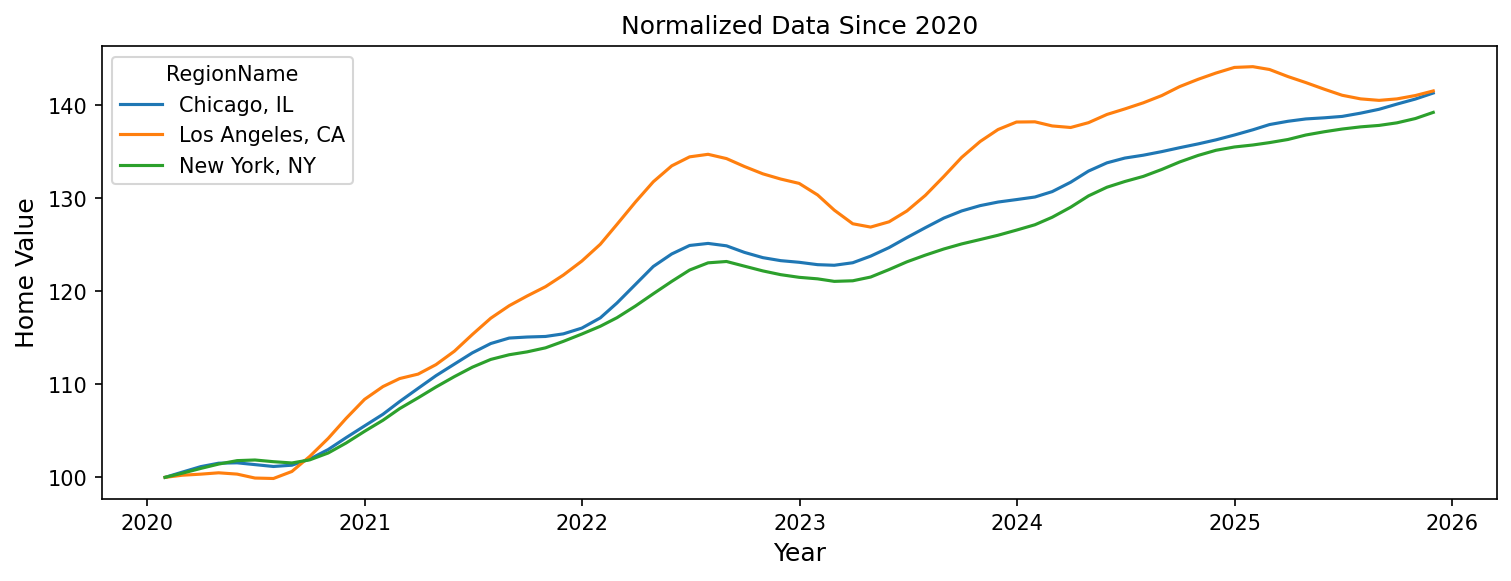

In [12]:
index_2020 = zhvi.normalized_from_date("2020-01-31")
long_df = index_2020.melt(
    id_vars=zhvi.META_DATA_COLS, 
    var_name='Date', 
    value_name='NormalizedValue'
)
long_df['Date'] = pd.to_datetime(long_df['Date'])
long_df = long_df.sort_values(['RegionName', 'Date'])

cities = ['Chicago, IL', 'New York, NY', 'Los Angeles, CA']
filtered_plot = long_df[long_df['RegionName'].isin(cities)]

plt.figure(figsize=(12, 4), dpi=150)
sns.lineplot(data=filtered_plot, x='Date', y='NormalizedValue', hue='RegionName')
plt.title("Normalized Data Since 2020")
plt.ylabel("Home Value", fontsize=12)
plt.xlabel("Year", fontsize=12)
plt.show()

In [13]:
long_df

,RegionID,SizeRank,RegionName,RegionType,StateName,latitude,longitude,Date,NormalizedValue
658,394297,677,"Aberdeen, SD",msa,SD,NaN,NaN,2020-01-31,100.000000
1553,394297,677,"Aberdeen, SD",msa,SD,NaN,NaN,2020-02-29,100.382709
2448,394297,677,"Aberdeen, SD",msa,SD,NaN,NaN,2020-03-31,100.560743
3343,394297,677,"Aberdeen, SD",msa,SD,NaN,NaN,2020-04-30,100.804259
4238,394297,677,"Aberdeen, SD",msa,SD,NaN,NaN,2020-05-31,101.105455
...,...,...,...,...,...,...,...,...,...
59960,753929,935,"Zapata, TX",msa,TX,NaN,NaN,2025-07-31,88.548714
60855,753929,935,"Zapata, TX",msa,TX,NaN,NaN,2025-08-31,88.226280
61750,753929,935,"Zapata, TX",msa,TX,NaN,NaN,2025-09-30,87.685063
62645,753929,935,"Zapata, TX",msa,TX,NaN,NaN,2025-10-31,86.992188


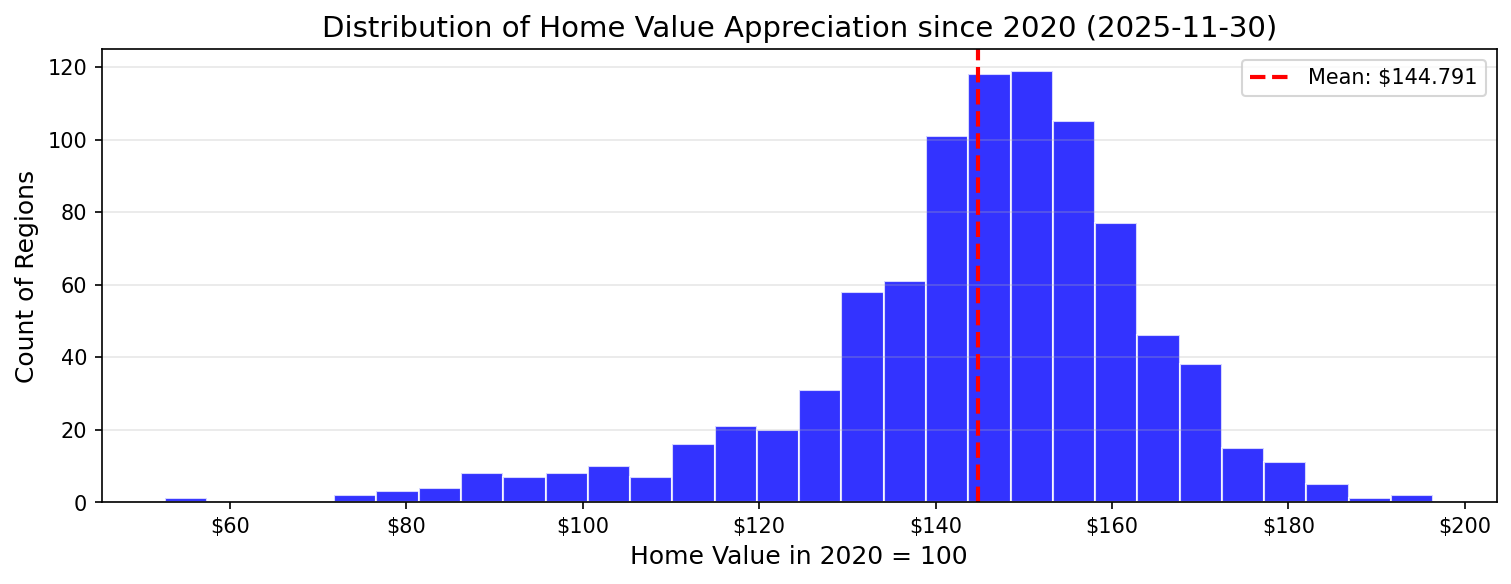

In [14]:
current_month_df = long_df[long_df["Date"] == latest_month]
current = current_month_df["NormalizedValue"].dropna()

mean_val = current.mean()

fig, ax = plt.subplots(figsize=(12, 4), dpi=150)

ax.hist(current, bins=30, color="blue", edgecolor='white', alpha=0.8)

formatter = ticker.StrMethodFormatter('${x:,.0f}')
ax.xaxis.set_major_formatter(formatter)

ax.set_title(f'Distribution of Home Value Appreciation since 2020 ({latest_month})', fontsize=14)
ax.set_ylabel("Count of Regions", fontsize=12)
ax.set_xlabel('Home Value in 2020 = 100', fontsize=12)
ax.axvline(mean_val, color='red', linestyle='dashed', linewidth=2, 
            label=f'Mean: ${mean_val:,.3f}')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.show()

## Change after event

In [15]:
delta = zhvi.change_after_event("2020-03-15", regions=["Chicago, IL", "Austin, TX"])
delta

,RegionID,SizeRank,RegionName,RegionType,StateName,latitude,longitude,plus_1_mon,plus_2_mon,plus_3_mon,plus_6_mon,plus_12_mon
3,394463,3,"Chicago, IL",msa,IL,NaN,NaN,100.364962,100.403776,100.212371,100.803349,108.322361
29,394355,29,"Austin, TX",msa,TX,NaN,NaN,100.682540,101.075641,101.316598,103.982358,118.347826


## Geocoding

In [16]:
location = geocoder.geocode("Chicago, IL")

In [17]:
location
pd.read_csv(cache_file)

,query,address,latitude,longitude
0,"Chicago, IL","Chicago, South Chicago Township, Cook County, ...",41.875562,-87.624421


In [19]:
zhvi.geocode_regions(["Chicago, IL"])
zhvi.df.iloc[[3]]

,RegionID,SizeRank,RegionName,RegionType,StateName,2000-01-31,2000-02-29,2000-03-31,2000-04-30,2000-05-31,...,2025-04-30,2025-05-31,2025-06-30,2025-07-31,2025-08-31,2025-09-30,2025-10-31,2025-11-30,latitude,longitude
3,394463,3,"Chicago, IL",msa,IL,151721.660042,151862.110101,152129.599712,152795.047391,153595.500906,...,327914.592965,328201.936285,328558.836926,329388.734181,330373.317156,331691.388829,332981.532008,334511.78674,41.875562,-87.624421
